In [4]:
%pip install importlib_resources

Note: you may need to restart the kernel to use updated packages.


In [5]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import importlib_resources
import numpy as np

In [6]:
#Descargar el set de datos
datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 0 url [00:00, ? url/s]
Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...:   0%|                                  | 0/1 [00:00<?, ? url/s]
Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...:   0%|                                  | 0/2 [00:00<?, ? url/s]
Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...:   0%|                                  | 0/3 [00:00<?, ? url/s]
Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...:   0%|                                  | 0/4 [00:00<?, ? url/s]
Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...:   0%|                                  | 0/4 [00:00<?, ? url/s]
Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...:   0%|                                  | 0/4 [00:00<?, ? url/s]
Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Size...:   0%|                                      | 0/25 [00:00<?, ? MiB/s]

Dl Size...:   0%|                                      | 0/29 [00:00<?, ? MiB/s]

Dl Size...:   0%|                                      | 0

Dataset fashion_mnist downloaded and prepared to /Users/maureentellez/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


### Escribe para que sirven los parametros ###
- as_supervised:
  Este parámetro indica que los datos se carguen en forma de pares: una entrada y su etiqueta.
- with_info: Este parámetro permite obtener información adicional sobre el dataset, como la cantidad de datos, las categorías disponibles y una descripción general del conjunto de datos.

In [7]:
#imprimir los metadatos
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='/Users/maureentellez/tensorflow_datasets/fashion_mnist/3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBL

In [8]:
#Obtenemos los datos de entrenamiento
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

In [10]:
#Asignar nombres de las categorías
nombres_clases = metadatos.features['label'].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [11]:
#Normalizamos los datos
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255 #aqui pasa 0-255 a 0-1
    return imagenes, etiquetas

In [12]:
#regresa todos los datos de entrenamiento 
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

### Escribir para que se usa la función map() ###
- map(): Se utiliza para aplicar una misma función a todos los elementos de un conjunto de datos

In [14]:
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

2026-03-09 17:25:26.692547: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:25:26.692617: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


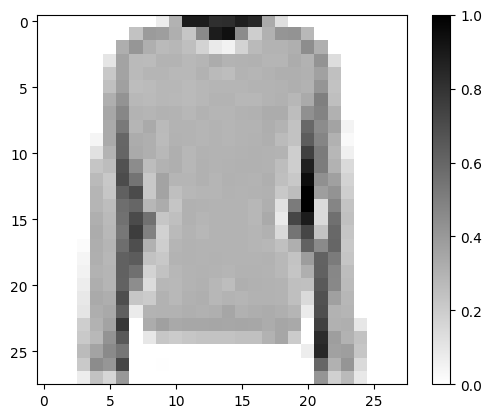

In [16]:
#Mostrar una imagen de los datos de prueba
for imagen, etiqueta in datos_entrenamiento.take(1):
    break
imagen = imagen.numpy().reshape((28,28)) #Redimensionar los pixeles

#Dibujar
plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

2026-03-09 17:29:17.811974: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:29:17.812345: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:29:17.814713: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence

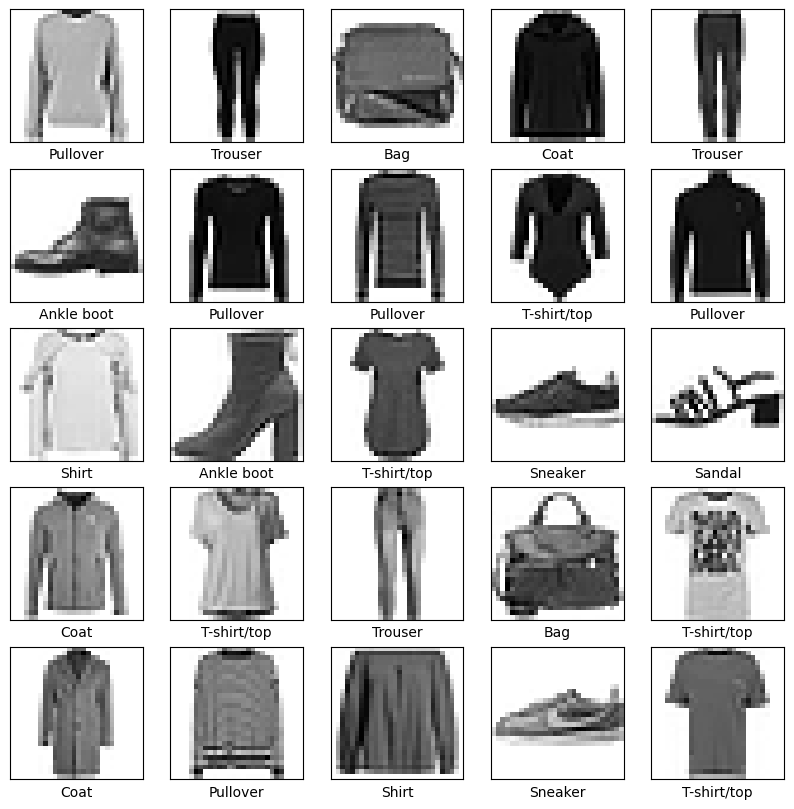

In [18]:
#Mostrar una imagen por cada categoría con su eriqueta

plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28,28))
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])
plt.show()

In [19]:
#creamos el modelo
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)), #1 - blanco y negro
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
#compilar modelo
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [21]:
#Dividimos el modelo por lotes
TAMANO_LOTE = 32

In [22]:
#los numeros de datos en entrenamiento y pruebas (60k y 10k)
num_ej_entrenamiento = metadatos.splits["train"].num_examples
num_ej_pruebas = metadatos.splits["test"].num_examples
print(num_ej_entrenamiento)
print(num_ej_pruebas)

60000
10000


In [23]:
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)


In [25]:
#Entrenando al modelo
historial = modelo.fit(datos_entrenamiento, epochs=5,steps_per_epoch = math.ceil(num_ej_entrenamiento/TAMANO_LOTE))

Epoch 1/5


2026-03-09 17:43:27.908754: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.7944 - loss: 0.5861
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8155 - loss: 0.5465
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8020 - loss: 0.6743
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7929 - loss: 0.8544
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.7736 - loss: 1.2607


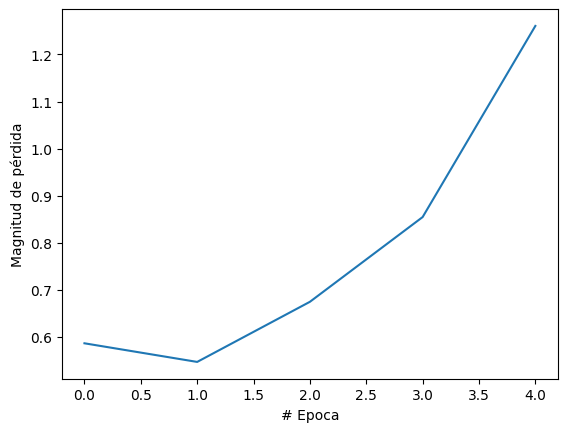

In [27]:
#Ver la función de perdida
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


2026-03-09 17:47:18.122289: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:47:18.122615: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:47:18.127723: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence

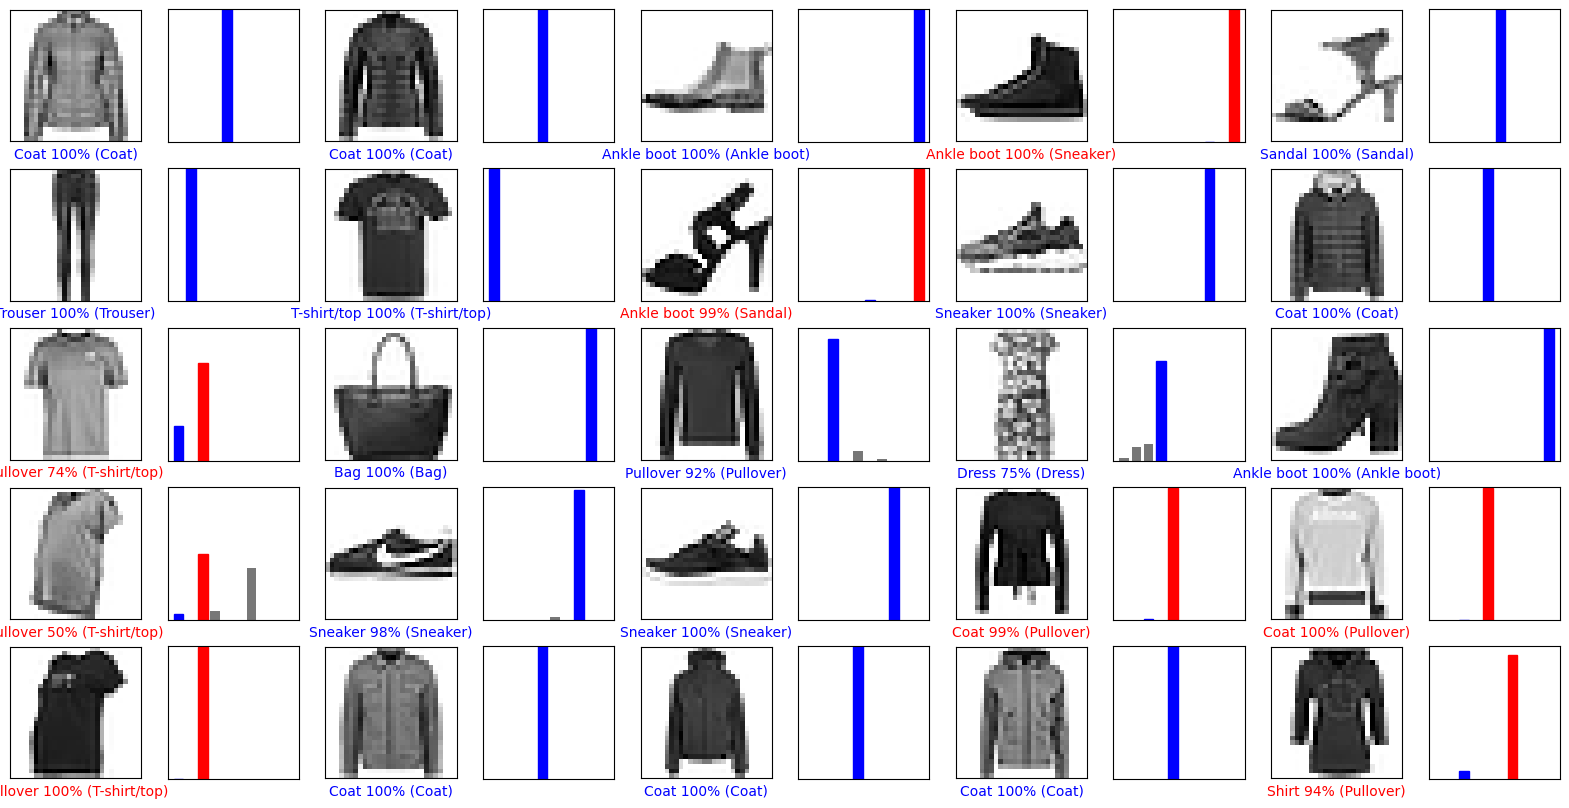

In [29]:
#Crear una cuadrícula con varias predicciones, y marcar si fue correcta (azul) o incorrecta (roja)
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()

predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[...,0], cmap=plt.cm.binary)

    etiqueta_prediccion = np.argmax(arr_predicciones)
    if etiqueta_prediccion == etiqueta_real:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(nombres_clases[etiqueta_prediccion],
                                         100*np.max(arr_predicciones),
                                         nombres_clases[etiqueta_real]),
                                         color=color)

def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0, 1])
    etiqueta_prediccion = np.argmax(arr_predicciones)

    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

filas = 5
columnas = 5
num_imagenes = filas * columnas
plt.figure(figsize=(2*2*columnas, 2*filas))

for i in range(num_imagenes):
    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
    plt.subplot(filas, 2*columnas, 2*i+2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

In [32]:
#Realizar predicción de una imagen
imagen = imagenes_prueba[24]
imagen = np.array([imagen])
prediccion = modelo.predict(imagen)

print ("Predicción: " + nombres_clases[np.argmax(prediccion[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicción: Shirt


# Codigo Iteractivo #

### ¿Qué es h5? ###
Es un tipo de archivo que se utiliza para guardar modelos de aprendizaje automático y redes neuronales. Sirve para almacenar la estructura del modelo, los pesos que aprendió durante el entrenamiento y, en algunos casos, también la configuración utilizada. Esto permite reutilizar el modelo después sin necesidad de volver a entrenarlo desde cero.

In [33]:
%pip install pillow ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 10.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 24.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]
Note: you may need to restart the kernel to use updated packages.


In [39]:
import io
from PIL import Image
import ipywidgets as widgets
from IPython.display import display


In [47]:
import io
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Widget para subir imagen
subir_imagen = widgets.FileUpload(accept='image/*', multiple=False)

# Botón para ejecutar predicción
boton_predecir = widgets.Button(description="Predecir")

# Área de salida donde se mostrará todo
salida = widgets.Output()

display(subir_imagen, boton_predecir, salida)

def predecir(_):
    with salida:
        clear_output()
        if len(subir_imagen.value) == 0:
            print("Primero sube una imagen.")
            return

        archivo = subir_imagen.value[0]
        contenido = archivo["content"].tobytes()

        # Abrir imagen
        img = Image.open(io.BytesIO(contenido)).convert('L')
        img = img.resize((28, 28))

        img_array = np.array(img).astype(np.float32)

        # Invertir colores
        img_array = 255 - img_array

        # Normalizar
        img_array = img_array / 255.0

        # Formato para el modelo
        img_modelo = img_array.reshape(1, 28, 28, 1)

        # Predicción
        prediccion = modelo.predict(img_modelo)
        clase_predicha = np.argmax(prediccion[0])
        confianza = np.max(prediccion[0]) * 100

        # Mostrar imagen
        plt.figure(figsize=(4,4))
        plt.imshow(img_array, cmap=plt.cm.binary)
        plt.title(f"Predicción: {nombres_clases[clase_predicha]}\nConfianza: {confianza:.2f}%")
        plt.axis("off")
        plt.show()

        # Mostrar probabilidades
        plt.figure(figsize=(10,4))
        plt.bar(nombres_clases, prediccion[0], color="#777777")
        plt.xticks(rotation=45)
        plt.ylim([0,1])
        plt.title("Probabilidades por clase")
        plt.show()

        print("Predicción:", nombres_clases[clase_predicha])
        print("Confianza:", f"{confianza:.2f}%")

boton_predecir.on_click(predecir)

FileUpload(value=(), accept='image/*', description='Upload')

Button(description='Predecir', style=ButtonStyle())

Output()

In [48]:
modelo.save("modelo_ropa.h5")